#**Challenge Telecom X: análise de evasão de clientes 🏬**


> *Neste desafio de análise de dados na Telecom X, realiza-se a investigação da evasão de clientes (churn) por meio da coleta, tratamento e análise de dados com Python. O projeto envolve a importação de dados via API, aplicação do processo de ETL, criação de visualizações para identificar padrões e a realização de uma Análise Exploratória de Dados (EDA), gerando insights que auxiliam no desenvolvimento de estratégias para reduzir cancelamentos.*

> [Dicionário dos dados.](https://github.com/alura-cursos/challenge2-data-science/blob/main/TelecomX_dicionario.md)

---

## Load libs ⏬


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
import pandas as pd

In [31]:
import numpy as np

## Environment Confgs 🌳

In [32]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

df = pd.read_json(url)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


---


## 01 - Transformação 🪄




> Foram realizadas etapas de tratamento e preparação dos dados para garantir maior consistência nas análises. Inicialmente, buscou-se compreender a estrutura do conjunto de dados. Em seguida, foram verificadas possíveis inconsistências nas informações, que posteriormente foram tratadas. Por fim, realizou-se a padronização e transformação dos dados, tornando o conjunto mais adequado para as etapas de análise.

#### Normalizando colunas 🔧

In [33]:
norm_customer = pd.json_normalize(df['customer'])
norm_customer.head()

,gender,SeniorCitizen,Partner,Dependents,tenure
0,Female,0,Yes,Yes,9
1,Male,0,No,No,9
2,Male,0,No,No,4
3,Male,1,Yes,No,13
4,Female,1,Yes,No,3


In [34]:
norm_phone = pd.json_normalize(df['phone'])
norm_phone.head()

,PhoneService,MultipleLines
0,Yes,No
1,Yes,Yes
2,Yes,No
3,Yes,No
4,Yes,No


In [35]:
norm_internet = pd.json_normalize(df['internet'])
norm_internet.head()

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,DSL,No,Yes,No,Yes,Yes,No
1,DSL,No,No,No,No,No,Yes
2,Fiber optic,No,No,Yes,No,No,No
3,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,Fiber optic,No,No,No,Yes,Yes,No


In [36]:
norm_account = pd.json_normalize(df['account'])
norm_account.head()

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,One year,Yes,Mailed check,65.6,593.3
1,Month-to-month,No,Mailed check,59.9,542.4
2,Month-to-month,Yes,Electronic check,73.9,280.85
3,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Month-to-month,Yes,Mailed check,83.9,267.4


#### Concatenando o DataFrame 🤝

In [37]:
df_normal = df[['customerID', 'Churn']]

In [38]:
df_final = pd.concat([df_normal, norm_customer, norm_phone, norm_internet, norm_account], axis=1)
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [39]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [40]:
df_final['Charges.Total']

,Charges.Total
0,593.3
1,542.4
2,280.85
3,1237.85
4,267.4
...,...
7262,742.9
7263,1873.7
7264,92.75
7265,4627.65


#### Tratando as Inconsistências ✍️

In [41]:
bool_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

In [42]:
df_final[bool_cols] = (df_final[bool_cols] == 'Yes').astype(int)
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.3
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.4


In [43]:
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   int64  
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   int64  
 11  OnlineBackup      7267 non-null   int64  
 12  DeviceProtection  7267 non-null   int64  
 13  TechSupport       7267 non-null   int64  
 14  StreamingTV       7267 non-null   int64  
 15  StreamingMovies   7267 non-null   int64  
 16  Contract          7267 non-null   object 


In [44]:
df_final.columns = [col.lower() for col in df_final.columns]
df_final.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges.monthly,charges.total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


In [45]:
df_final.columns = df_final.columns.str.replace('[^a-zA-Z0-9\-\']', '', regex=True)
df_final.head()

<>:1: SyntaxWarning: invalid escape sequence '\-'
<>:1: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_165/3848292563.py:1: SyntaxWarning: invalid escape sequence '\-'
  df_final.columns = df_final.columns.str.replace('[^a-zA-Z0-9\-\']', '', regex=True)


,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,chargesmonthly,chargestotal
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


---


## 02 - Carga e Análise 🔍




> Foram realizadas análises exploratórias com o objetivo de compreender melhor o comportamento da evasão de clientes. Inicialmente, foi feita uma análise descritiva do conjunto de dados. Em seguida, analisou-se a distribuição da evasão e a contagem de cancelamentos em relação às variáveis categóricas e numéricas, possibilitando a identificação de padrões e relações relevantes para a compreensão do problema.

#### Calculando métricas 🧮

In [46]:
df_metricas = df_final.describe()
df_metricas

,churn,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,chargesmonthly,chargestotal
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2280.634213
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.632997
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,400.225000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1391.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3785.300000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000


#### Distribuição da Evasão 💨

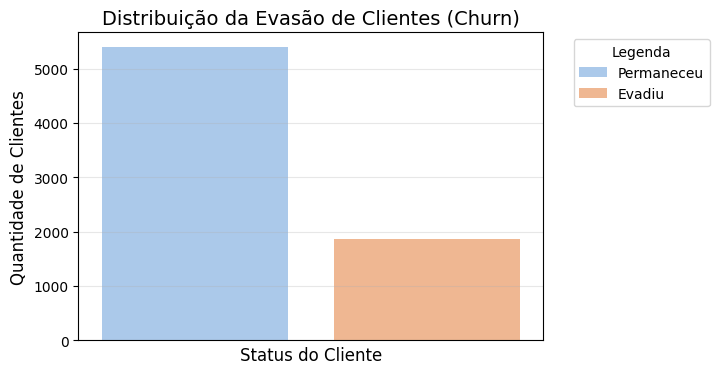

In [47]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data = df_final,
    x = 'churn',
    hue = 'churn',
    palette = 'pastel'
)

ax.set_xticks([])
plt.title('Distribuição da Evasão de Clientes (Churn)', fontsize = 14)
plt.xlabel('Status do Cliente', fontsize = 12)
plt.ylabel('Quantidade de Clientes', fontsize = 12)
plt.legend(title='Legenda', labels=['Permaneceu', 'Evadiu'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis = 'y', alpha = 0.3, zorder = 0)
plt.show()

#### Evasão por categorias 📊

/tmp/ipykernel_165/1393558725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


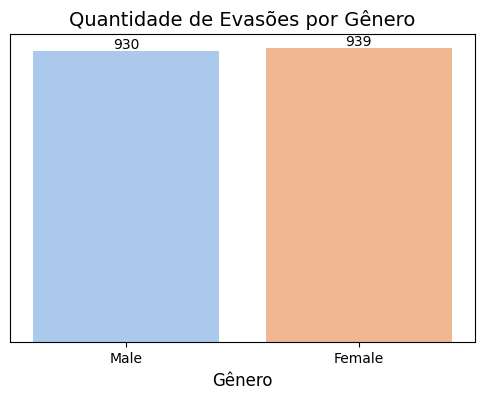

In [48]:
plt.figure(figsize=(6, 4))

df_evadiu = df_final[df_final['churn'] == 1]

ax = sns.countplot(
    data = df_evadiu,
    x = 'gender',
    palette = 'pastel'
)

plt.title('Quantidade de Evasões por Gênero', fontsize = 14)
plt.xlabel('Gênero', fontsize = 12)
plt.ylabel('')
plt.yticks([])


for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.grid(False)

plt.show()

In [49]:
# evasões por tipo de contrato
# apenas quem evadiu
df_evadiu = df_final[df_final['churn'] == 1]

#tabela base
tabela_contrato = df_evadiu['contract'].value_counts().reset_index()
tabela_contrato.columns = ['Tipo de Contrato', 'Quantidade de Evasões']

total_evasoes = tabela_contrato['Quantidade de Evasões'].sum()
tabela_contrato['Porcentagem'] = tabela_contrato['Quantidade de Evasões'] / total_evasoes

# estilização
tabela_cont_evas = (
    tabela_contrato.style
    .hide(axis='index')
    .format({
        'Quantidade de Evasões': '{:,}',
        'Porcentagem': '{:.2%}'
    })
    .background_gradient(subset=['Quantidade de Evasões', 'Porcentagem'], cmap='Reds')
    .set_properties(**{'text-align': 'center', 'border': '1px solid lightgrey'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('text-align', 'center'), ('background-color', '#ffffff'), ('font-weight', 'bold'), ('color', 'black')]
    }])
)

display(tabela_cont_evas)

Tipo de Contrato,Quantidade de Evasões,Porcentagem
Month-to-month,"1,655",88.55%
One year,166,8.88%
Two year,48,2.57%


In [50]:
#evasão por metodo de pag
df_evadiu = df_final[df_final['churn'] == 1]

#tabela base
tabela_pagamento = df_evadiu['paymentmethod'].value_counts().reset_index()
tabela_pagamento.columns = ['Método de Pagamento', 'Quantidade de Evasões']

total_evasoes = tabela_pagamento['Quantidade de Evasões'].sum()
tabela_pagamento['Porcentagem'] = tabela_pagamento['Quantidade de Evasões'] / total_evasoes

#estilização
tabela_pag_evas = (
    tabela_pagamento.style
    .hide(axis='index')
    .format({
        'Quantidade de Evasões': '{:,}',
        'Porcentagem': '{:.2%}'
    })
    .background_gradient(subset=['Quantidade de Evasões', 'Porcentagem'], cmap='Reds')
    .set_properties(**{'text-align': 'center', 'border': '1px solid lightgrey'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('text-align', 'center'), ('background-color', '#ffffff'), ('font-weight', 'bold'), ('color', 'black')]
    }])
)

display(tabela_pag_evas)

Método de Pagamento,Quantidade de Evasões,Porcentagem
Electronic check,"1,071",57.30%
Mailed check,308,16.48%
Bank transfer (automatic),258,13.80%
Credit card (automatic),232,12.41%


/tmp/ipykernel_165/1224272324.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


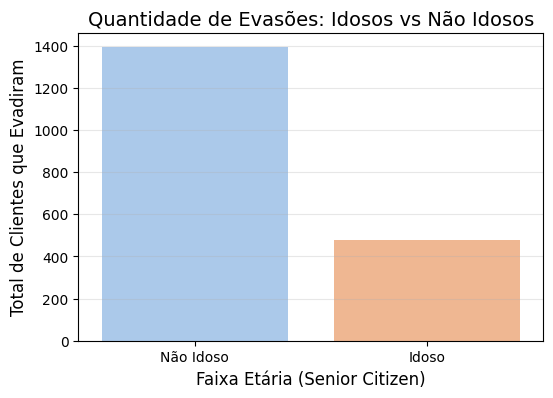

In [51]:
#evasão por clientes idosos
plt.figure(figsize=(6, 4))

df_evadiu = df_final[df_final['churn'] == 1]

ax = sns.countplot(
    data = df_evadiu,
    x = 'seniorcitizen',
    palette = 'pastel'
)

plt.xticks(ticks=[0, 1], labels=['Não Idoso', 'Idoso'])
plt.title('Quantidade de Evasões: Idosos vs Não Idosos', fontsize = 14)
plt.xlabel('Faixa Etária (Senior Citizen)', fontsize = 12)
plt.ylabel('Total de Clientes que Evadiram', fontsize = 12)
plt.grid(axis = 'y', alpha = 0.3, zorder = 0)

plt.show()

####Evasão por variáveis numéricas 🔢

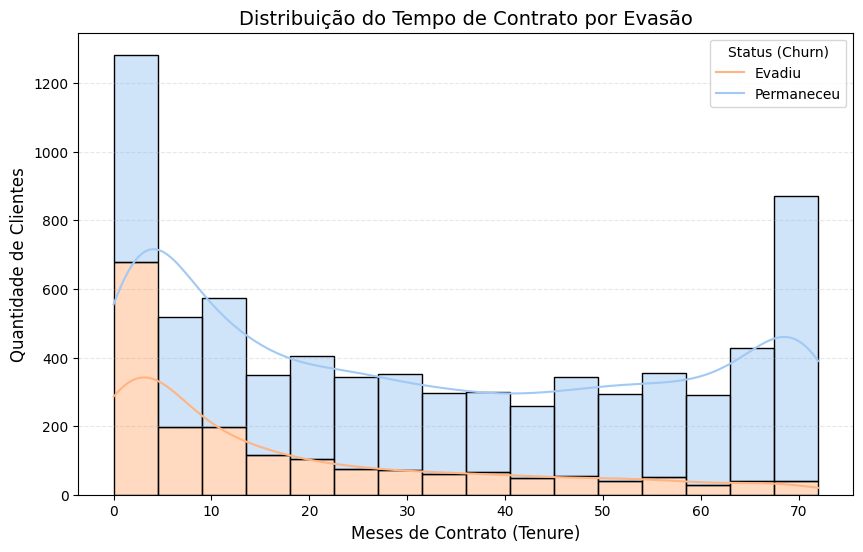

In [52]:
#evasão por tempo que o cliente usou os serviços
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_final,
    x='tenure',
    hue='churn',
    multiple='stack',
    kde=True,
    palette='pastel'
)

plt.legend(title='Status (Churn)', labels=['Evadiu', 'Permaneceu'])
plt.title('Distribuição do Tempo de Contrato por Evasão', fontsize=14)
plt.xlabel('Meses de Contrato (Tenure)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

# Grade para facilitar a leitura
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.show()

/tmp/ipykernel_165/1906726740.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


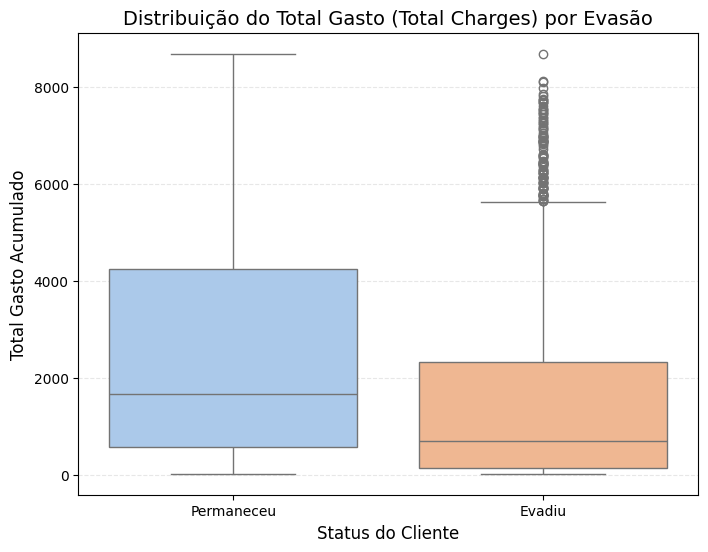

In [53]:
#distribuição de evasão por total gasto
plt.figure(figsize=(8, 6))

sns.boxplot(
    data = df_final,
    x = 'churn',
    y = 'chargestotal',
    palette = 'pastel'
)

plt.xticks(ticks=[0, 1], labels=['Permaneceu', 'Evadiu'])
plt.title('Distribuição do Total Gasto (Total Charges) por Evasão', fontsize=14)
plt.xlabel('Status do Cliente', fontsize=12)
plt.ylabel('Total Gasto Acumulado', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.show()

---


## 03 - Relatório Final 📝




> Após a extração dos dados, foi realizada a etapa de transformação para possibilitar sua manipulação e análise. A partir desse processo, foi possível investigar a problemática proposta. A seguir, apresenta-se um relatório detalhado com conclusões fundamentadas nos gráficos gerados e nas tabelas elaboradas.

## 1. Introdução
O presente projeto tem como objetivo analisar o problema de evasão de clientes, conhecido como **Churn**, na empresa de telecomunicações Telecom X. O Churn é uma métrica crítica para o negócio, pois reter um cliente atual é financeiramente mais vantajoso do que conquistar um novo.

Através da análise exploratória da base de dados fornecida, buscamos entender o perfil dos clientes que estão abandonando os serviços, identificar padrões de comportamento e fornecer subsídios para que a equipe de negócios possa tomar decisões estratégicas focadas na retenção e fidelização.

## 2. Limpeza e Tratamento de Dados
Para garantir a integridade da análise, a base de dados em formato JSON passou por um rigoroso processo de tratamento:
* **Achatamento (Flattening):** Os dados aninhados no JSON original foram expandidos utilizando a função de normalização do Pandas, transformando chaves internas em colunas tabulares acessíveis.
* **Padronização de Colunas:** Os nomes das colunas foram higienizados utilizando Expressões Regulares (Regex) para remover caracteres especiais e padronizados para letras minúsculas.
* **Tratamento de Tipos de Dados:** A coluna correspondente ao total gasto (`chargestotal`) foi convertida de texto (string) para o formato numérico (`float64`). Identificamos clientes recém-chegados (com tempo de contrato igual a zero) que possuíam espaços em branco `" "` nessa coluna, os quais foram tratados como valores nulos (`NaN`).
* **Ajuste da Variável Alvo:** A coluna de Churn foi mapeada para uma representação binária (`0` = permaneceu, `1` = evadiu).

## 3. Análise Exploratória de Dados
A exploração visual dos dados revelou características cruciais sobre os clientes que evadem:
* **Perfil Demográfico:** A análise indicou que o gênero não possui impacto significativo na decisão de evasão. No entanto, a proporção de evasão entre clientes **idosos** é consideravelmente mais alta em comparação aos não idosos.
* **Tipos de Contrato:** Identificamos um forte padrão financeiro: a esmagadora maioria das evasões ocorre em contratos do tipo **"Month-to-month" (mensais)**.
* **Métodos de Pagamento:** Clientes que utilizam **"Electronic check" (Boleto/Cheque Eletrônico)** lideram as taxas de cancelamento, contrastando com a estabilidade dos clientes com débito automático ou cartão de crédito.
* **Tempo de Permanência (`tenure`):** O histograma revelou que o risco de evasão é **altíssimo nos primeiros meses**. Se o cliente ultrapassa a barreira do primeiro ano, a probabilidade de cancelamento cai drasticamente.

## 4. Conclusões e Insights
A síntese das análises indica que o "cliente de risco" da Telecom X possui um perfil bem definido: ele adquire o serviço sem fidelidade (contrato mensal), realiza pagamentos de forma manual (electronic check) e tende a cancelar o serviço nos primeiros meses de uso. Além disso, o público idoso enfrenta algum atrito com o serviço ou atendimento, refletindo em uma taxa de abandono desproporcional ao seu tamanho na base.

## 5. Recomendações
Com base nos insights extraídos, sugerimos as seguintes ações estratégicas para reduzir o Churn:
* **Incentivo a Contratos Longos e Pagamentos Automáticos:** Oferecer descontos nas primeiras mensalidades ou upgrades para clientes que optarem por contratos de 1 ano ou cadastrarem o pagamento em débito automático/cartão de crédito.
* **Programa de Boas-Vindas (Onboarding):** Como a evasão é altíssima nos primeiros meses, criar um acompanhamento especial (suporte proativo, tutoriais de uso) nos primeiros 90 dias pode melhorar a percepção de valor.
* **Atenção ao Público Idoso:** Realizar uma pesquisa qualitativa com os clientes idosos para entender o motivo da evasão (dificuldade tecnológica, custo, suporte) e, eventualmente, criar um canal de atendimento simplificado.